# 08 2026 YTD Analysis

## Purpose

This notebook evaluates Germany's latest available international tourism performance in 2026 using year-to-date accommodation data.

The analysis compares January–June 2026 with the equivalent January–June period in 2025 to determine whether Germany's international tourism performance is strengthening, weakening, or remaining broadly stable.

Germany's 2026 performance is also benchmarked against other EU27 destinations using comparable reporting periods.

## Analytical Scope

The primary comparison period is:

- January–June 2025
- January–June 2026

Only equivalent months are compared. Full-year 2025 totals are not compared directly with partial-year 2026 totals.

For EU27 benchmarking, only countries with complete data for all six months from January through June are included in each indicator-specific comparison.

Foreign overnight stays have complete January–June 2026 coverage across the EU27 dataset.

Foreign arrivals require additional completeness screening because not every EU27 country has six reported months available for the comparison period.

The analysis therefore prioritizes comparability over maximizing the number of countries included.

## Business Questions

1. How did Germany's foreign arrivals change in January–June 2026 compared with January–June 2025?
2. How did foreign overnight stays change over the same period?
3. Has Germany's average length of stay increased or decreased?
4. Which months contributed most to the 2026 YTD change?
5. How does Germany's 2026 YTD growth compare with other EU27 destinations?
6. Has Germany's competitive ranking changed during the latest available period?
7. Do the 2026 results reinforce or challenge the historical competitiveness findings from earlier notebooks?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

project_root = Path.cwd().parent

clean_dir = (
    project_root
    / "data"
    / "clean"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

figures_dir = (
    project_root
    / "figures"
)

print(
    "Project root:",
    project_root
)

Project root: /Users/jannoelvero/Documents/germany_eu_tourism_analysis


In [2]:
germany_nights = pd.read_csv(
    clean_dir
    / "germany_foreign_nights_monthly_clean.csv"
)

germany_arrivals = pd.read_csv(
    clean_dir
    / "germany_foreign_arrivals_monthly_clean.csv"
)

eu_nights = pd.read_csv(
    clean_dir
    / "eu27_foreign_nights_monthly_clean.csv"
)

eu_arrivals = pd.read_csv(
    clean_dir
    / "eu27_foreign_arrivals_monthly_clean.csv"
)

print(
    "Germany nights:",
    germany_nights.shape
)

print(
    "Germany arrivals:",
    germany_arrivals.shape
)

print(
    "EU27 nights:",
    eu_nights.shape
)

print(
    "EU27 arrivals:",
    eu_arrivals.shape
)

Germany nights: (67, 11)
Germany arrivals: (67, 11)
EU27 nights: (1809, 14)
EU27 arrivals: (1809, 14)


In [3]:
print(
    "GERMANY NIGHTS"
)

print(
    germany_nights.columns.tolist()
)

print(
    "\nGERMANY ARRIVALS"
)

print(
    germany_arrivals.columns.tolist()
)

print(
    "\nEU27 NIGHTS"
)

print(
    eu_nights.columns.tolist()
)

print(
    "\nEU27 ARRIVALS"
)

print(
    eu_arrivals.columns.tolist()
)

GERMANY NIGHTS
['country_code', 'country', 'period', 'foreign_nights', 'status', 'year', 'month', 'value_available', 'date', 'months_available', 'complete_12_month_year']

GERMANY ARRIVALS
['country_code', 'country', 'period', 'foreign_arrivals', 'status', 'year', 'month', 'value_available', 'date', 'months_available', 'complete_12_month_year']

EU27 NIGHTS
['country_code', 'country', 'period', 'foreign_nights', 'status', 'year', 'month', 'value_available', 'is_estimated', 'is_low_reliability', 'is_confidential', 'date', 'months_available', 'complete_12_month_year']

EU27 ARRIVALS
['country_code', 'country', 'period', 'foreign_arrivals', 'status', 'year', 'month', 'value_available', 'is_estimated', 'is_low_reliability', 'is_confidential', 'date', 'months_available', 'complete_12_month_year']


In [4]:
display(
    germany_nights[
        germany_nights[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    ]
    .tail(20)
)

,country_code,country,period,foreign_nights,status,year,month,value_available,date,months_available,complete_12_month_year
48,DE,Germany,2025-01,4242218.0,NaN,2025,1,True,2025-01-01,12,True
49,DE,Germany,2025-02,4949805.0,NaN,2025,2,True,2025-02-01,12,True
50,DE,Germany,2025-03,5220357.0,NaN,2025,3,True,2025-03-01,12,True
51,DE,Germany,2025-04,6556296.0,NaN,2025,4,True,2025-04-01,12,True
52,DE,Germany,2025-05,7484744.0,NaN,2025,5,True,2025-05-01,12,True
53,DE,Germany,2025-06,7530964.0,NaN,2025,6,True,2025-06-01,12,True
54,DE,Germany,2025-07,10358796.0,NaN,2025,7,True,2025-07-01,12,True
55,DE,Germany,2025-08,9689151.0,NaN,2025,8,True,2025-08-01,12,True
56,DE,Germany,2025-09,7674317.0,NaN,2025,9,True,2025-09-01,12,True
57,DE,Germany,2025-10,7195093.0,NaN,2025,10,True,2025-10-01,12,True


In [5]:
display(
    germany_arrivals[
        germany_arrivals[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    ]
    .tail(20)
)

,country_code,country,period,foreign_arrivals,status,year,month,value_available,date,months_available,complete_12_month_year
48,DE,Germany,2025-01,1869061.0,NaN,2025,1,True,2025-01-01,12,True
49,DE,Germany,2025-02,2180842.0,NaN,2025,2,True,2025-02-01,12,True
50,DE,Germany,2025-03,2294956.0,NaN,2025,3,True,2025-03-01,12,True
51,DE,Germany,2025-04,2898714.0,NaN,2025,4,True,2025-04-01,12,True
52,DE,Germany,2025-05,3329016.0,NaN,2025,5,True,2025-05-01,12,True
53,DE,Germany,2025-06,3447435.0,NaN,2025,6,True,2025-06-01,12,True
54,DE,Germany,2025-07,4666150.0,NaN,2025,7,True,2025-07-01,12,True
55,DE,Germany,2025-08,4229612.0,NaN,2025,8,True,2025-08-01,12,True
56,DE,Germany,2025-09,3451143.0,NaN,2025,9,True,2025-09-01,12,True
57,DE,Germany,2025-10,3171850.0,NaN,2025,10,True,2025-10-01,12,True


In [6]:
germany_2026_coverage = pd.DataFrame(
    {
        "indicator": [
            "Foreign Nights",
            "Foreign Arrivals"
        ],
        "available_months_2026": [
            germany_nights.loc[
                germany_nights[
                    "year"
                ] == 2026,
                "foreign_nights"
            ].notna().sum(),

            germany_arrivals.loc[
                germany_arrivals[
                    "year"
                ] == 2026,
                "foreign_arrivals"
            ].notna().sum()
        ]
    }
)

display(
    germany_2026_coverage
)

,indicator,available_months_2026
0,Foreign Nights,6
1,Foreign Arrivals,6


In [7]:
eu_nights_h1_2026 = eu_nights[
    (
        eu_nights[
            "year"
        ] == 2026
    )
    &
    (
        eu_nights[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

eu_nights_coverage = (
    eu_nights_h1_2026
    .groupby(
        [
            "country_code",
            "country"
        ],
        as_index=False
    )
    .agg(
        available_months=(
            "foreign_nights",
            lambda x: x.notna().sum()
        )
    )
)

display(
    eu_nights_coverage
    .sort_values(
        [
            "available_months",
            "country"
        ]
    )
)

,country_code,country,available_months
0,AT,Austria,6
1,BE,Belgium,6
2,BG,Bulgaria,6
12,HR,Croatia,6
3,CY,Cyprus,6
4,CZ,Czechia,6
6,DK,Denmark,6
7,EE,Estonia,6
10,FI,Finland,6
11,FR,France,6


In [8]:
eu_arrivals_h1_2026 = eu_arrivals[
    (
        eu_arrivals[
            "year"
        ] == 2026
    )
    &
    (
        eu_arrivals[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

eu_arrivals_coverage = (
    eu_arrivals_h1_2026
    .groupby(
        [
            "country_code",
            "country"
        ],
        as_index=False
    )
    .agg(
        available_months=(
            "foreign_arrivals",
            lambda x: x.notna().sum()
        )
    )
)

display(
    eu_arrivals_coverage
    .sort_values(
        [
            "available_months",
            "country"
        ]
    )
)

,country_code,country,available_months
22,PT,Portugal,4
0,AT,Austria,6
1,BE,Belgium,6
2,BG,Bulgaria,6
12,HR,Croatia,6
3,CY,Cyprus,6
4,CZ,Czechia,6
6,DK,Denmark,6
7,EE,Estonia,6
10,FI,Finland,6


In [9]:
print(
    "Countries with complete Jan-Jun nights:",
    (
        eu_nights_coverage[
            "available_months"
        ] == 6
    ).sum()
)

print(
    "Countries with complete Jan-Jun arrivals:",
    (
        eu_arrivals_coverage[
            "available_months"
        ] == 6
    ).sum()
)

print(
    "\nIncomplete arrivals countries:"
)

display(
    eu_arrivals_coverage[
        eu_arrivals_coverage[
            "available_months"
        ] < 6
    ]
)

Countries with complete Jan-Jun nights: 27
Countries with complete Jan-Jun arrivals: 26

Incomplete arrivals countries:


,country_code,country,available_months
22,PT,Portugal,4


In [10]:
germany_nights_h1 = germany_nights[
    (
        germany_nights[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    )
    &
    (
        germany_nights[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

germany_arrivals_h1 = germany_arrivals[
    (
        germany_arrivals[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    )
    &
    (
        germany_arrivals[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

In [11]:
germany_h1_nights = (
    germany_nights_h1
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        foreign_nights=(
            "foreign_nights",
            "sum"
        )
    )
)

germany_h1_arrivals = (
    germany_arrivals_h1
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        foreign_arrivals=(
            "foreign_arrivals",
            "sum"
        )
    )
)

In [12]:
germany_h1_summary = (
    germany_h1_arrivals
    .merge(
        germany_h1_nights,
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

germany_h1_summary[
    "avg_length_of_stay"
] = (
    germany_h1_summary[
        "foreign_nights"
    ]
    / germany_h1_summary[
        "foreign_arrivals"
    ]
)

display(
    germany_h1_summary.round(2)
)

,year,foreign_arrivals,foreign_nights,avg_length_of_stay
0,2025,16020024.0,35984384.0,2.25
1,2026,16346103.0,36249231.0,2.22


In [13]:
germany_h1_summary[
    "arrivals_growth_pct"
] = (
    germany_h1_summary[
        "foreign_arrivals"
    ]
    .pct_change()
    * 100
)

germany_h1_summary[
    "nights_growth_pct"
] = (
    germany_h1_summary[
        "foreign_nights"
    ]
    .pct_change()
    * 100
)

germany_h1_summary[
    "los_change_pct"
] = (
    germany_h1_summary[
        "avg_length_of_stay"
    ]
    .pct_change()
    * 100
)

display(
    germany_h1_summary.round(2)
)

,year,foreign_arrivals,foreign_nights,avg_length_of_stay,arrivals_growth_pct,nights_growth_pct,los_change_pct
0,2025,16020024.0,35984384.0,2.25,NaN,NaN,NaN
1,2026,16346103.0,36249231.0,2.22,2.04,0.74,-1.27


In [46]:
eu_nights_growth[
    "nights_scale_rank_2026"
] = (
    eu_nights_growth[
        "nights_h1_2026"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

eu_nights_growth[
    "nights_growth_rank"
] = (
    eu_nights_growth[
        "nights_growth_pct"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

display(
    eu_nights_growth[
        eu_nights_growth[
            "country_code"
        ] == "DE"
    ]
    .round(2)
)

,country_code,country,nights_h1_2025,nights_h1_2026,nights_growth_pct,nights_scale_rank_2026,nights_growth_rank
5,DE,Germany,35984384.0,36249231.0,0.74,6,20


In [14]:
germany_h1_summary[
    "arrivals_change"
] = (
    germany_h1_summary[
        "foreign_arrivals"
    ]
    .diff()
)

germany_h1_summary[
    "nights_change"
] = (
    germany_h1_summary[
        "foreign_nights"
    ]
    .diff()
)

germany_h1_summary[
    "los_change_nights"
] = (
    germany_h1_summary[
        "avg_length_of_stay"
    ]
    .diff()
)

display(
    germany_h1_summary.round(2)
)

,year,foreign_arrivals,foreign_nights,avg_length_of_stay,arrivals_growth_pct,nights_growth_pct,los_change_pct,arrivals_change,nights_change,los_change_nights
0,2025,16020024.0,35984384.0,2.25,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,16346103.0,36249231.0,2.22,2.04,0.74,-1.27,326079.0,264847.0,-0.03


In [15]:
monthly_nights_comparison = (
    germany_nights_h1[
        [
            "year",
            "month",
            "foreign_nights"
        ]
    ]
    .pivot(
        index="month",
        columns="year",
        values="foreign_nights"
    )
    .reset_index()
)

monthly_nights_comparison.columns.name = None

monthly_nights_comparison = (
    monthly_nights_comparison.rename(
        columns={
            2025: "nights_2025",
            2026: "nights_2026"
        }
    )
)

monthly_nights_comparison[
    "nights_change"
] = (
    monthly_nights_comparison[
        "nights_2026"
    ]
    - monthly_nights_comparison[
        "nights_2025"
    ]
)

monthly_nights_comparison[
    "nights_growth_pct"
] = (
    monthly_nights_comparison[
        "nights_change"
    ]
    / monthly_nights_comparison[
        "nights_2025"
    ]
    * 100
)

display(
    monthly_nights_comparison.round(2)
)

,month,nights_2025,nights_2026,nights_change,nights_growth_pct
0,1,4242218.0,4277203.0,34985.0,0.82
1,2,4949805.0,5078278.0,128473.0,2.60
2,3,5220357.0,5197078.0,-23279.0,-0.45
3,4,6556296.0,6596278.0,39982.0,0.61
4,5,7484744.0,7446648.0,-38096.0,-0.51
5,6,7530964.0,7653746.0,122782.0,1.63


In [16]:
monthly_arrivals_comparison = (
    germany_arrivals_h1[
        [
            "year",
            "month",
            "foreign_arrivals"
        ]
    ]
    .pivot(
        index="month",
        columns="year",
        values="foreign_arrivals"
    )
    .reset_index()
)

monthly_arrivals_comparison.columns.name = None

monthly_arrivals_comparison = (
    monthly_arrivals_comparison.rename(
        columns={
            2025: "arrivals_2025",
            2026: "arrivals_2026"
        }
    )
)

monthly_arrivals_comparison[
    "arrivals_change"
] = (
    monthly_arrivals_comparison[
        "arrivals_2026"
    ]
    - monthly_arrivals_comparison[
        "arrivals_2025"
    ]
)

monthly_arrivals_comparison[
    "arrivals_growth_pct"
] = (
    monthly_arrivals_comparison[
        "arrivals_change"
    ]
    / monthly_arrivals_comparison[
        "arrivals_2025"
    ]
    * 100
)

display(
    monthly_arrivals_comparison.round(2)
)

,month,arrivals_2025,arrivals_2026,arrivals_change,arrivals_growth_pct
0,1,1869061.0,1938956.0,69895.0,3.74
1,2,2180842.0,2271693.0,90851.0,4.17
2,3,2294956.0,2341823.0,46867.0,2.04
3,4,2898714.0,2934984.0,36270.0,1.25
4,5,3329016.0,3353419.0,24403.0,0.73
5,6,3447435.0,3505228.0,57793.0,1.68


In [47]:
eu_h1_benchmark = (
    eu_arrivals_growth_comparable[
        [
            "country_code",
            "country",
            "arrivals_h1_2025",
            "arrivals_h1_2026",
            "arrivals_growth_pct"
        ]
    ]
    .merge(
        eu_nights_growth[
            [
                "country_code",
                "nights_h1_2025",
                "nights_h1_2026",
                "nights_growth_pct"
            ]
        ],
        on="country_code",
        how="inner",
        validate="one_to_one"
    )
)

eu_h1_benchmark[
    "los_h1_2025"
] = (
    eu_h1_benchmark[
        "nights_h1_2025"
    ]
    / eu_h1_benchmark[
        "arrivals_h1_2025"
    ]
)

eu_h1_benchmark[
    "los_h1_2026"
] = (
    eu_h1_benchmark[
        "nights_h1_2026"
    ]
    / eu_h1_benchmark[
        "arrivals_h1_2026"
    ]
)

eu_h1_benchmark[
    "los_change_pct"
] = (
    (
        eu_h1_benchmark[
            "los_h1_2026"
        ]
        / eu_h1_benchmark[
            "los_h1_2025"
        ]
    )
    - 1
) * 100

eu_h1_benchmark[
    "los_rank_2026"
] = (
    eu_h1_benchmark[
        "los_h1_2026"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

print(
    "Comparable LOS countries:",
    len(
        eu_h1_benchmark
    )
)

display(
    eu_h1_benchmark[
        eu_h1_benchmark[
            "country_code"
        ] == "DE"
    ]
    .round(2)
)

Comparable LOS countries: 25


,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct,nights_h1_2025,nights_h1_2026,nights_growth_pct,los_h1_2025,los_h1_2026,los_change_pct,los_rank_2026
4,DE,Germany,16020024.0,16346103.0,2.04,35984384.0,36249231.0,0.74,2.25,2.22,-1.27,20


In [35]:
print(
    eu_arrivals_growth[
        [
            "country_code",
            "country",
            "arrivals_h1_2025",
            "arrivals_h1_2026",
            "arrivals_growth_pct"
        ]
    ]
    .isna()
    .sum()
)

country_code           0
country                0
arrivals_h1_2025       1
arrivals_h1_2026       1
arrivals_growth_pct    2
dtype: int64


In [36]:
display(
    eu_arrivals_growth[
        eu_arrivals_growth[
            [
                "arrivals_h1_2025",
                "arrivals_h1_2026",
                "arrivals_growth_pct"
            ]
        ]
        .isna()
        .any(
            axis=1
        )
    ]
)

,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct
2,BG,Bulgaria,NaN,1433550.0,NaN
22,PT,Portugal,8919037.0,NaN,NaN


In [45]:
eu_arrivals_growth_comparable[
    "arrivals_growth_rank"
] = (
    eu_arrivals_growth_comparable[
        "arrivals_growth_pct"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

display(
    eu_arrivals_growth_comparable[
        eu_arrivals_growth_comparable[
            "country_code"
        ] == "DE"
    ]
    .round(2)
)

,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct,arrivals_scale_rank_2026,arrivals_growth_rank
5,DE,Germany,16020024.0,16346103.0,2.04,4,17


In [17]:
monthly_h1_comparison = (
    monthly_arrivals_comparison
    .merge(
        monthly_nights_comparison,
        on="month",
        how="inner",
        validate="one_to_one"
    )
)

In [18]:
monthly_h1_comparison[
    "los_2025"
] = (
    monthly_h1_comparison[
        "nights_2025"
    ]
    / monthly_h1_comparison[
        "arrivals_2025"
    ]
)

monthly_h1_comparison[
    "los_2026"
] = (
    monthly_h1_comparison[
        "nights_2026"
    ]
    / monthly_h1_comparison[
        "arrivals_2026"
    ]
)

monthly_h1_comparison[
    "los_change"
] = (
    monthly_h1_comparison[
        "los_2026"
    ]
    - monthly_h1_comparison[
        "los_2025"
    ]
)

monthly_h1_comparison[
    "los_change_pct"
] = (
    monthly_h1_comparison[
        "los_change"
    ]
    / monthly_h1_comparison[
        "los_2025"
    ]
    * 100
)

In [19]:
display(
    monthly_h1_comparison[
        [
            "month",
            "arrivals_2025",
            "arrivals_2026",
            "arrivals_growth_pct",
            "nights_2025",
            "nights_2026",
            "nights_growth_pct",
            "los_2025",
            "los_2026",
            "los_change",
            "los_change_pct"
        ]
    ]
    .round(2)
)

,month,arrivals_2025,arrivals_2026,arrivals_growth_pct,nights_2025,nights_2026,nights_growth_pct,los_2025,los_2026,los_change,los_change_pct
0,1,1869061.0,1938956.0,3.74,4242218.0,4277203.0,0.82,2.27,2.21,-0.06,-2.81
1,2,2180842.0,2271693.0,4.17,4949805.0,5078278.0,2.60,2.27,2.24,-0.03,-1.51
2,3,2294956.0,2341823.0,2.04,5220357.0,5197078.0,-0.45,2.27,2.22,-0.06,-2.44
3,4,2898714.0,2934984.0,1.25,6556296.0,6596278.0,0.61,2.26,2.25,-0.01,-0.63
4,5,3329016.0,3353419.0,0.73,7484744.0,7446648.0,-0.51,2.25,2.22,-0.03,-1.23
5,6,3447435.0,3505228.0,1.68,7530964.0,7653746.0,1.63,2.18,2.18,-0.00,-0.05


In [20]:
monthly_direction_summary = pd.DataFrame(
    {
        "indicator": [
            "Arrivals",
            "Nights",
            "Length of Stay"
        ],
        "months_increased": [
            (
                monthly_h1_comparison[
                    "arrivals_growth_pct"
                ] > 0
            ).sum(),

            (
                monthly_h1_comparison[
                    "nights_growth_pct"
                ] > 0
            ).sum(),

            (
                monthly_h1_comparison[
                    "los_change"
                ] > 0
            ).sum()
        ],
        "months_decreased": [
            (
                monthly_h1_comparison[
                    "arrivals_growth_pct"
                ] < 0
            ).sum(),

            (
                monthly_h1_comparison[
                    "nights_growth_pct"
                ] < 0
            ).sum(),

            (
                monthly_h1_comparison[
                    "los_change"
                ] < 0
            ).sum()
        ]
    }
)

display(
    monthly_direction_summary
)

,indicator,months_increased,months_decreased
0,Arrivals,6,0
1,Nights,4,2
2,Length of Stay,0,6


In [21]:
eu_nights_h1 = eu_nights[
    (
        eu_nights[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    )
    &
    (
        eu_nights[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

In [22]:
eu_nights_h1_summary = (
    eu_nights_h1
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ],
        as_index=False
    )
    .agg(
        foreign_nights=(
            "foreign_nights",
            "sum"
        ),
        available_months=(
            "foreign_nights",
            lambda x: x.notna().sum()
        )
    )
)

In [23]:
eu_nights_h1_complete = (
    eu_nights_h1_summary[
        eu_nights_h1_summary[
            "available_months"
        ] == 6
    ]
    .copy()
)

In [24]:
eu_nights_growth = (
    eu_nights_h1_complete
    .pivot(
        index=[
            "country_code",
            "country"
        ],
        columns="year",
        values="foreign_nights"
    )
    .reset_index()
)

eu_nights_growth.columns.name = None

eu_nights_growth = (
    eu_nights_growth.rename(
        columns={
            2025: "nights_h1_2025",
            2026: "nights_h1_2026"
        }
    )
)

In [25]:
eu_nights_growth[
    "nights_growth_pct"
] = (
    (
        eu_nights_growth[
            "nights_h1_2026"
        ]
        /
        eu_nights_growth[
            "nights_h1_2025"
        ]
    )
    - 1
) * 100

print(
    "Comparable countries:",
    len(
        eu_nights_growth
    )
)

display(
    eu_nights_growth
    .sort_values(
        "nights_growth_pct",
        ascending=False
    )
    .round(2)
)

Comparable countries: 27


,country_code,country,nights_h1_2025,nights_h1_2026,nights_growth_pct
14,IE,Ireland,10137480.0,12730245.0,25.58
16,LT,Lithuania,1572668.0,1834744.0,16.66
19,MT,Malta,5279206.0,5897989.0,11.72
26,SK,Slovakia,2387064.0,2633862.0,10.34
21,PL,Poland,8618215.0,9343611.0,8.42
6,DK,Denmark,6344376.0,6876113.0,8.38
25,SI,Slovenia,4860704.0,5193898.0,6.85
7,EE,Estonia,1614971.0,1722610.0,6.67
23,RO,Romania,2338233.0,2482187.0,6.16
15,IT,Italy,124756347.0,130264470.0,4.42


In [26]:
eu_arrivals_h1 = eu_arrivals[
    (
        eu_arrivals[
            "year"
        ].isin(
            [
                2025,
                2026
            ]
        )
    )
    &
    (
        eu_arrivals[
            "month"
        ].between(
            1,
            6
        )
    )
].copy()

In [27]:
eu_arrivals_h1_summary = (
    eu_arrivals_h1
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ],
        as_index=False
    )
    .agg(
        foreign_arrivals=(
            "foreign_arrivals",
            "sum"
        ),
        available_months=(
            "foreign_arrivals",
            lambda x: x.notna().sum()
        )
    )
)

eu_arrivals_h1_complete = (
    eu_arrivals_h1_summary[
        eu_arrivals_h1_summary[
            "available_months"
        ] == 6
    ]
    .copy()
)

In [28]:
eu_arrivals_growth = (
    eu_arrivals_h1_complete
    .pivot(
        index=[
            "country_code",
            "country"
        ],
        columns="year",
        values="foreign_arrivals"
    )
    .reset_index()
)

eu_arrivals_growth.columns.name = None

eu_arrivals_growth = (
    eu_arrivals_growth.rename(
        columns={
            2025: "arrivals_h1_2025",
            2026: "arrivals_h1_2026"
        }
    )
)

In [29]:
eu_arrivals_growth[
    "arrivals_growth_pct"
] = (
    (
        eu_arrivals_growth[
            "arrivals_h1_2026"
        ]
        /
        eu_arrivals_growth[
            "arrivals_h1_2025"
        ]
    )
    - 1
) * 100

print(
    "Comparable countries:",
    len(
        eu_arrivals_growth
    )
)

display(
    eu_arrivals_growth
    .sort_values(
        "arrivals_growth_pct",
        ascending=False
    )
    .round(2)
)

Comparable countries: 27


,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct
19,MT,Malta,1188014.0,1384400.0,16.53
14,IE,Ireland,1787612.0,2064757.0,15.50
26,SK,Slovakia,1022919.0,1134594.0,10.92
21,PL,Poland,3781465.0,4177998.0,10.49
6,DK,Denmark,1579168.0,1707600.0,8.13
23,RO,Romania,1110861.0,1191595.0,7.27
20,NL,Netherlands,10064823.0,10693404.0,6.25
25,SI,Slovenia,2075688.0,2197134.0,5.85
24,SE,Sweden,3223322.0,3406328.0,5.68
7,EE,Estonia,831762.0,874903.0,5.19


In [37]:
eu_arrivals_growth[
    "arrivals_scale_rank_2026"
] = (
    eu_arrivals_growth[
        "arrivals_h1_2026"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

eu_arrivals_growth[
    "arrivals_growth_rank"
] = (
    eu_arrivals_growth[
        "arrivals_growth_pct"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

display(
    eu_arrivals_growth[
        eu_arrivals_growth[
            "country_code"
        ] == "DE"
    ]
    .round(2)
)

,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct,arrivals_scale_rank_2026,arrivals_growth_rank
5,DE,Germany,16020024.0,16346103.0,2.04,4,17


In [39]:
eu_nights_growth[
    "nights_scale_rank_2026"
] = (
    eu_nights_growth[
        "nights_h1_2026"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

eu_nights_growth[
    "nights_growth_rank"
] = (
    eu_nights_growth[
        "nights_growth_pct"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

In [40]:
eu_h1_benchmark = (
    eu_arrivals_growth[
        [
            "country_code",
            "country",
            "arrivals_h1_2025",
            "arrivals_h1_2026",
            "arrivals_growth_pct"
        ]
    ]
    .merge(
        eu_nights_growth[
            [
                "country_code",
                "nights_h1_2025",
                "nights_h1_2026",
                "nights_growth_pct"
            ]
        ],
        on="country_code",
        how="inner",
        validate="one_to_one"
    )
)

In [41]:
eu_h1_benchmark[
    "los_h1_2025"
] = (
    eu_h1_benchmark[
        "nights_h1_2025"
    ]
    / eu_h1_benchmark[
        "arrivals_h1_2025"
    ]
)

eu_h1_benchmark[
    "los_h1_2026"
] = (
    eu_h1_benchmark[
        "nights_h1_2026"
    ]
    / eu_h1_benchmark[
        "arrivals_h1_2026"
    ]
)

eu_h1_benchmark[
    "los_change_pct"
] = (
    (
        eu_h1_benchmark[
            "los_h1_2026"
        ]
        /
        eu_h1_benchmark[
            "los_h1_2025"
        ]
    )
    - 1
) * 100

In [43]:
eu_arrivals_growth[
    "arrivals_scale_rank_2026"
] = (
    eu_arrivals_growth[
        "arrivals_h1_2026"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

eu_arrivals_growth[
    "arrivals_growth_rank"
] = (
    eu_arrivals_growth[
        "arrivals_growth_pct"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

display(
    eu_arrivals_growth[
        eu_arrivals_growth[
            "country_code"
        ] == "DE"
    ]
    .round(2)
)

,country_code,country,arrivals_h1_2025,arrivals_h1_2026,arrivals_growth_pct,arrivals_scale_rank_2026,arrivals_growth_rank
5,DE,Germany,16020024.0,16346103.0,2.04,4,17


In [48]:
eu_los_benchmark_summary = pd.DataFrame({
    "benchmark": [
        "Germany",
        "EU Mean",
        "EU Median",
        "EU Weighted"
    ],
    "los_h1_2025": [
        eu_h1_benchmark.loc[
            eu_h1_benchmark["country_code"] == "DE",
            "los_h1_2025"
        ].iloc[0],

        eu_h1_benchmark["los_h1_2025"].mean(),

        eu_h1_benchmark["los_h1_2025"].median(),

        (
            eu_h1_benchmark["nights_h1_2025"].sum()
            / eu_h1_benchmark["arrivals_h1_2025"].sum()
        )
    ],
    "los_h1_2026": [
        eu_h1_benchmark.loc[
            eu_h1_benchmark["country_code"] == "DE",
            "los_h1_2026"
        ].iloc[0],

        eu_h1_benchmark["los_h1_2026"].mean(),

        eu_h1_benchmark["los_h1_2026"].median(),

        (
            eu_h1_benchmark["nights_h1_2026"].sum()
            / eu_h1_benchmark["arrivals_h1_2026"].sum()
        )
    ]
})

eu_los_benchmark_summary[
    "change_pct"
] = (
    (
        eu_los_benchmark_summary["los_h1_2026"]
        / eu_los_benchmark_summary["los_h1_2025"]
    )
    - 1
) * 100

display(
    eu_los_benchmark_summary.round(3)
)

,benchmark,los_h1_2025,los_h1_2026,change_pct
0,Germany,2.246,2.218,-1.274
1,EU Mean,2.963,2.985,0.734
2,EU Median,2.447,2.437,-0.400
3,EU Weighted,3.172,3.170,-0.046


In [49]:
germany_los_2026 = (
    eu_h1_benchmark.loc[
        eu_h1_benchmark["country_code"] == "DE",
        "los_h1_2026"
    ].iloc[0]
)

eu_mean_los_2026 = (
    eu_h1_benchmark["los_h1_2026"].mean()
)

eu_median_los_2026 = (
    eu_h1_benchmark["los_h1_2026"].median()
)

eu_weighted_los_2026 = (
    eu_h1_benchmark["nights_h1_2026"].sum()
    / eu_h1_benchmark["arrivals_h1_2026"].sum()
)

germany_los_gap_2026 = pd.DataFrame({
    "benchmark": [
        "EU Mean",
        "EU Median",
        "EU Weighted"
    ],
    "benchmark_los": [
        eu_mean_los_2026,
        eu_median_los_2026,
        eu_weighted_los_2026
    ]
})

germany_los_gap_2026[
    "germany_los"
] = germany_los_2026

germany_los_gap_2026[
    "gap_nights"
] = (
    germany_los_2026
    - germany_los_gap_2026["benchmark_los"]
)

display(
    germany_los_gap_2026.round(3)
)

,benchmark,benchmark_los,germany_los,gap_nights
0,EU Mean,2.985,2.218,-0.768
1,EU Median,2.437,2.218,-0.220
2,EU Weighted,3.170,2.218,-0.953


## 2026 YTD Interpretation

Germany's international tourism performance remained positive in scale during January–June 2026, but the latest data reinforce the country's stay-duration challenge.

Foreign arrivals increased by 2.04% compared with the same period in 2025, while foreign overnight stays increased by only 0.74%. As a result, aggregate average length of stay declined from 2.246 to 2.218 nights, a decrease of 1.27%.

The monthly pattern is particularly consistent. Foreign arrivals increased in all six months from January through June, while overnight stays increased in four months and declined in two. Average length of stay decreased in all six months.

Germany therefore continues to attract additional international visitors, but growth in visitor volume is not translating proportionally into overnight stays.

The EU comparison reinforces this finding. Germany ranked 4th in foreign-arrival scale among countries with complete January–June 2026 arrivals data and 6th in foreign overnight stays among all 27 EU countries. However, its growth performance was more moderate: Germany ranked 17th among the 25 countries with comparable 2025–2026 H1 arrivals data and 20th among 27 countries in overnight-stay growth.

Germany's H1 2026 average length of stay was 2.218 nights, ranking 20th among the 25 countries with complete comparable arrivals and nights data. This remained below the comparable-country EU median of 2.437 nights, mean of 2.985 nights, and weighted benchmark of 3.170 nights.

Importantly, Germany's 1.27% decline in average length of stay was not simply part of a uniform EU-wide decline. The comparable-country EU mean increased by 0.73%, the median declined by only 0.40%, and the weighted benchmark remained broadly stable at -0.05%.

The 2026 YTD evidence therefore reinforces the historical competitiveness finding: Germany remains a major European destination by international visitor volume, but comparatively short and continuing-to-decline stays limit the conversion of visitor arrivals into overnight-stay volume.

These results describe January–June performance only and should not be interpreted as a forecast of full-year 2026 outcomes.

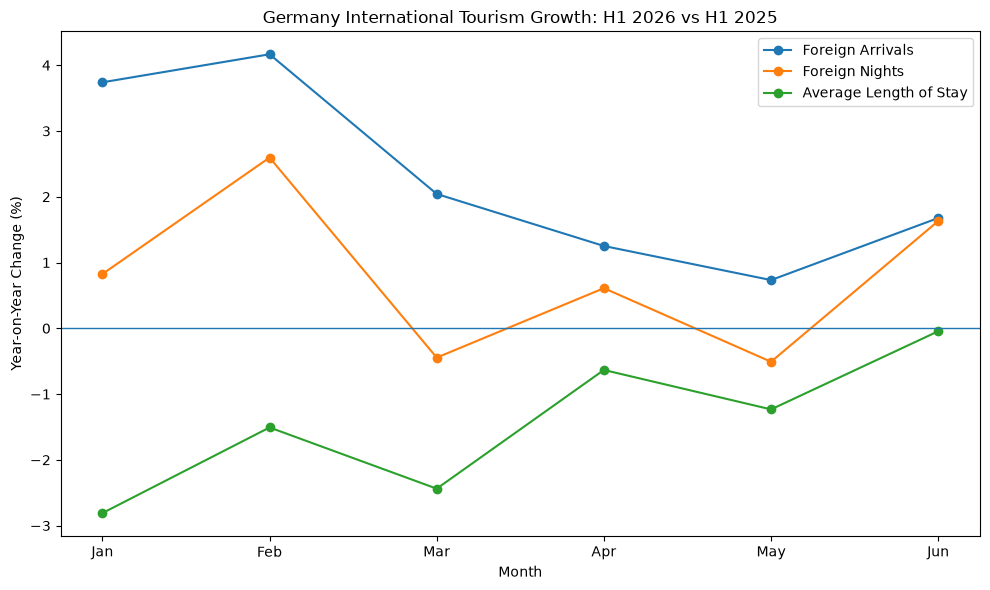

Saved: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures/germany_2026_ytd_growth_comparison.png


In [50]:
months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun"
]

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    months,
    monthly_h1_comparison["arrivals_growth_pct"],
    marker="o",
    label="Foreign Arrivals"
)

ax.plot(
    months,
    monthly_h1_comparison["nights_growth_pct"],
    marker="o",
    label="Foreign Nights"
)

ax.plot(
    months,
    monthly_h1_comparison["los_change_pct"],
    marker="o",
    label="Average Length of Stay"
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Germany International Tourism Growth: H1 2026 vs H1 2025"
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Year-on-Year Change (%)"
)

ax.legend()

plt.tight_layout()

figure_path = (
    figures_dir
    / "germany_2026_ytd_growth_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    figure_path
)

In [51]:
germany_h1_summary.to_csv(
    processed_dir
    / "germany_2026_ytd_summary.csv",
    index=False
)

monthly_h1_comparison.to_csv(
    processed_dir
    / "germany_2026_ytd_monthly_comparison.csv",
    index=False
)

eu_nights_growth.to_csv(
    processed_dir
    / "eu27_2026_ytd_nights_benchmark.csv",
    index=False
)

eu_arrivals_growth_comparable.to_csv(
    processed_dir
    / "eu27_2026_ytd_arrivals_growth_benchmark.csv",
    index=False
)

eu_h1_benchmark.to_csv(
    processed_dir
    / "eu27_2026_ytd_los_benchmark.csv",
    index=False
)

eu_los_benchmark_summary.to_csv(
    processed_dir
    / "germany_eu_2026_ytd_los_summary.csv",
    index=False
)

germany_los_gap_2026.to_csv(
    processed_dir
    / "germany_2026_ytd_los_gap.csv",
    index=False
)

print(
    "Notebook 08 processed outputs saved."
)

Notebook 08 processed outputs saved.


In [52]:
output_files = [
    "germany_2026_ytd_summary.csv",
    "germany_2026_ytd_monthly_comparison.csv",
    "eu27_2026_ytd_nights_benchmark.csv",
    "eu27_2026_ytd_arrivals_growth_benchmark.csv",
    "eu27_2026_ytd_los_benchmark.csv",
    "germany_eu_2026_ytd_los_summary.csv",
    "germany_2026_ytd_los_gap.csv"
]

for file_name in output_files:
    file_path = (
        processed_dir
        / file_name
    )

    print(
        file_name,
        "->",
        file_path.exists()
    )

germany_2026_ytd_summary.csv -> True
germany_2026_ytd_monthly_comparison.csv -> True
eu27_2026_ytd_nights_benchmark.csv -> True
eu27_2026_ytd_arrivals_growth_benchmark.csv -> True
eu27_2026_ytd_los_benchmark.csv -> True
germany_eu_2026_ytd_los_summary.csv -> True
germany_2026_ytd_los_gap.csv -> True


# Conclusion

The January–June 2026 results reinforce rather than challenge the competitiveness pattern identified in the historical analysis.

Germany remains one of Europe's largest international tourism destinations. Foreign arrivals increased by 2.04% and foreign overnight stays increased by 0.74% compared with January–June 2025. However, the slower growth in overnight stays caused average length of stay to decline by 1.27%, from 2.246 to 2.218 nights.

This decline was broad across the period rather than being driven by a single month. Arrivals increased in all six months, while average length of stay declined in every month.

Germany also retained a strong position by tourism scale, ranking 4th in available H1 2026 foreign arrivals and 6th in foreign overnight stays. Its growth rankings were weaker, however, placing 17th among 25 comparable countries for arrivals growth and 20th among all 27 EU countries for overnight-stay growth.

The stay-duration gap also remains substantial. Germany's H1 2026 LOS of 2.218 nights ranked 20th among 25 comparable countries and remained below the EU median, mean, and weighted benchmark.

Taken together with the historical, statistical, source-market, and competitiveness analyses, the latest data support a consistent strategic conclusion: Germany's principal tourism challenge is not simply attracting international visitors. It is improving the conversion of strong visitor volume into longer stays and greater overnight-stay depth.

The 2026 results cover January through June only. They represent a year-to-date performance assessment and should not be interpreted as a forecast of full-year 2026 tourism outcomes.